# 04 — Evaluation

Load best checkpoint, generate DDIM samples for every `(cluster_id × day_type)` combination, and run the full metric suite.

In [1]:
import shutil
import subprocess
import sys
import tempfile
import urllib.request
import zipfile
from pathlib import Path


def clone_repo(repo_url: str, target_dir: Path) -> None:
    result = subprocess.run(
        ['git', 'clone', '--depth', '1', repo_url, str(target_dir)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or result.stdout.strip() or 'git clone failed')


def download_repo_archive(archive_url: str, runtime_dir: Path, repo_dir: Path, extract_dir: Path, archive_path: Path) -> None:
    if archive_path.exists():
        archive_path.unlink()
    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    urllib.request.urlretrieve(archive_url, archive_path)
    with zipfile.ZipFile(archive_path, 'r') as archive:
        archive.extractall(runtime_dir)
    if repo_dir.exists():
        shutil.rmtree(repo_dir)
    shutil.move(str(extract_dir), str(repo_dir))


def find_or_bootstrap_repo_root() -> Path:
    candidates = [
        Path.cwd().resolve(),
        Path('/tmp/vscode-colab/tesina'),
        Path('/content/tesina'),
        Path('/home/nicola/Desktop/Supsi/tesina'),
    ]
    for base in candidates:
        for candidate in [base, *base.parents]:
            if (candidate / 'src').exists() and (candidate / 'data').exists():
                return candidate

    runtime_dir = Path(tempfile.gettempdir()) / 'vscode-colab'
    repo_dir = runtime_dir / 'tesina'
    archive_path = runtime_dir / 'tesina.zip'
    extract_dir = runtime_dir / 'tesina-master'
    repo_url = 'https://github.com/ncapac/tesina.git'
    archive_url = 'https://codeload.github.com/ncapac/tesina/zip/refs/heads/master'

    runtime_dir.mkdir(parents=True, exist_ok=True)
    if repo_dir.exists() and not (repo_dir / 'src').exists():
        shutil.rmtree(repo_dir)

    if not repo_dir.exists():
        try:
            clone_repo(repo_url, repo_dir)
        except Exception:
            download_repo_archive(archive_url, runtime_dir, repo_dir, extract_dir, archive_path)

    if (repo_dir / 'src').exists() and (repo_dir / 'data').exists():
        return repo_dir

    raise RuntimeError('Could not locate or bootstrap the tesina project root from the current notebook kernel.')


REPO_ROOT = find_or_bootstrap_repo_root()
DATA_DIR = REPO_ROOT / 'data'
CHECKPOINT_DIR = REPO_ROOT / 'checkpoints'

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from src.data.loader    import load_raw, compute_stats, normalize, denormalize
from src.data.dataset   import make_windows, train_val_split, numpy_dataloader
from src.models.transformer1d import DiffusionTransformer1D
from src.models.diffusion     import DiffusionProcess
from src.training.train       import Trainer
from src.evaluation.metrics   import run_all_metrics

plt.rcParams['figure.dpi'] = 110
GUIDANCE_SCALE = 1.5
N_SAMPLES      = 500    # synthetic samples per condition
print('Project root:', REPO_ROOT)
print('JAX devices:', jax.devices())

Project root: /tmp/vscode-colab/tesina
JAX devices: [CudaDevice(id=0)]


## 1. Reload data & cluster labels

In [2]:
df = load_raw(DATA_DIR / 'power.pk')
clusters_df   = pd.read_csv(DATA_DIR / 'clusters.csv')
cluster_labels = clusters_df['cluster_id'].values
N_CLUSTERS     = int(cluster_labels.max()) + 1

timestamps = df.index if isinstance(df.index, pd.DatetimeIndex) else None

stats   = compute_stats(df, cluster_labels)
df_norm = normalize(df, stats, cluster_labels)

xs, cs, mid = make_windows(df_norm, cluster_labels, timestamps)
x_train, c_train, x_val, c_val = train_val_split(xs, cs, mid, n_meters=df.shape[1])
print(f'Total windows : {xs.shape[0]}')
print(f'Train windows : {x_train.shape[0]}')
print(f'Val windows   : {x_val.shape[0]}')
print(f'Clusters      : {N_CLUSTERS}  ({[(c_val[:,0]==i).sum() for i in range(N_CLUSTERS)]} val windows each)')


Total windows : 351816
Train windows : 299208
Val windows   : 52608
Clusters      : 3  ([np.int64(30688), np.int64(5480), np.int64(16440)] val windows each)


## 2. Load checkpoint

In [3]:
key = jax.random.PRNGKey(99)

model = DiffusionTransformer1D(
    seq_len=24, d_model=128, n_heads=4, n_layers=4, d_ff=256,
    n_clusters=N_CLUSTERS, n_day_types=2, n_months=12, n_dow=7, key=key,
)
diffusion = DiffusionProcess(T=1000, freq_loss_weight=0.05)
trainer   = Trainer(model, diffusion, checkpoint_dir=str(CHECKPOINT_DIR))
trainer.load('best_model.pkl')
print('Checkpoint loaded.')


  ✓ checkpoint loaded ← /tmp/vscode-colab/tesina/checkpoints/best_model.pkl  (step 23375)
Checkpoint loaded.


## 3. Generate samples per condition

In [4]:

conditions = [
    (cid, dt, 'Weekday' if dt == 0 else 'Weekend')
    for cid in range(N_CLUSTERS)
    for dt in range(2)
]

results = {}     # condition label → {'real': ndarray, 'synthetic': ndarray}

for cid, dt, day_name in conditions:
    label = f'cluster{cid}_{day_name.lower()}'

    # Select matching real windows
    mask = (c_val[:, 0] == cid) & (c_val[:, 1] == dt)
    real_windows = x_val[mask]           # (n_real, 24)
    if real_windows.shape[0] == 0:
        print(f'  [SKIP] {label}: no real windows found')
        continue

    # Generate: month=5 (June), representative dow per day_type
    rep_dow = 1 if dt == 0 else 5   # Tuesday / Saturday
    c_batch = jnp.array([[cid, dt, 5, rep_dow]] * N_SAMPLES, dtype=jnp.int32)
    gen_key = jax.random.PRNGKey(cid * 100 + dt)
    synth = diffusion.ddim_sample(
        trainer.model, c_batch,
        seq_len=24, batch_size=N_SAMPLES,
        key=gen_key, n_steps=50, guidance_scale=GUIDANCE_SCALE
    )
    synth = np.array(synth)             # (N_SAMPLES, 24)

    results[label] = {'real': real_windows, 'synthetic': synth, 'cluster': cid, 'day_type': dt}
    print(f'  {label}: {real_windows.shape[0]:4d} real | {N_SAMPLES} synthetic')


  cluster0_weekday: 21924 real | 100 synthetic
  cluster0_weekend: 8764 real | 100 synthetic
  cluster1_weekday: 3915 real | 100 synthetic
  cluster1_weekend: 1565 real | 100 synthetic
  cluster2_weekday: 11745 real | 100 synthetic
  cluster2_weekend: 4695 real | 100 synthetic


## 4. Run metrics for each condition


=== cluster0_weekday ===

=== cluster0_weekend ===

=== cluster1_weekday ===

=== cluster1_weekend ===

=== cluster2_weekday ===

=== cluster2_weekend ===

--- Summary ---
                    acf_l2      crps  discriminative_acc
condition                                               
cluster0_weekday  1.579972  0.335532            0.850000
cluster0_weekend  1.540194  0.320821            0.850000
cluster1_weekday  1.758880  0.242870            0.883333
cluster1_weekend  1.782526  0.256837            0.983333
cluster2_weekday  0.662272  1.527980            0.950000
cluster2_weekend  0.467447  1.048038            0.950000


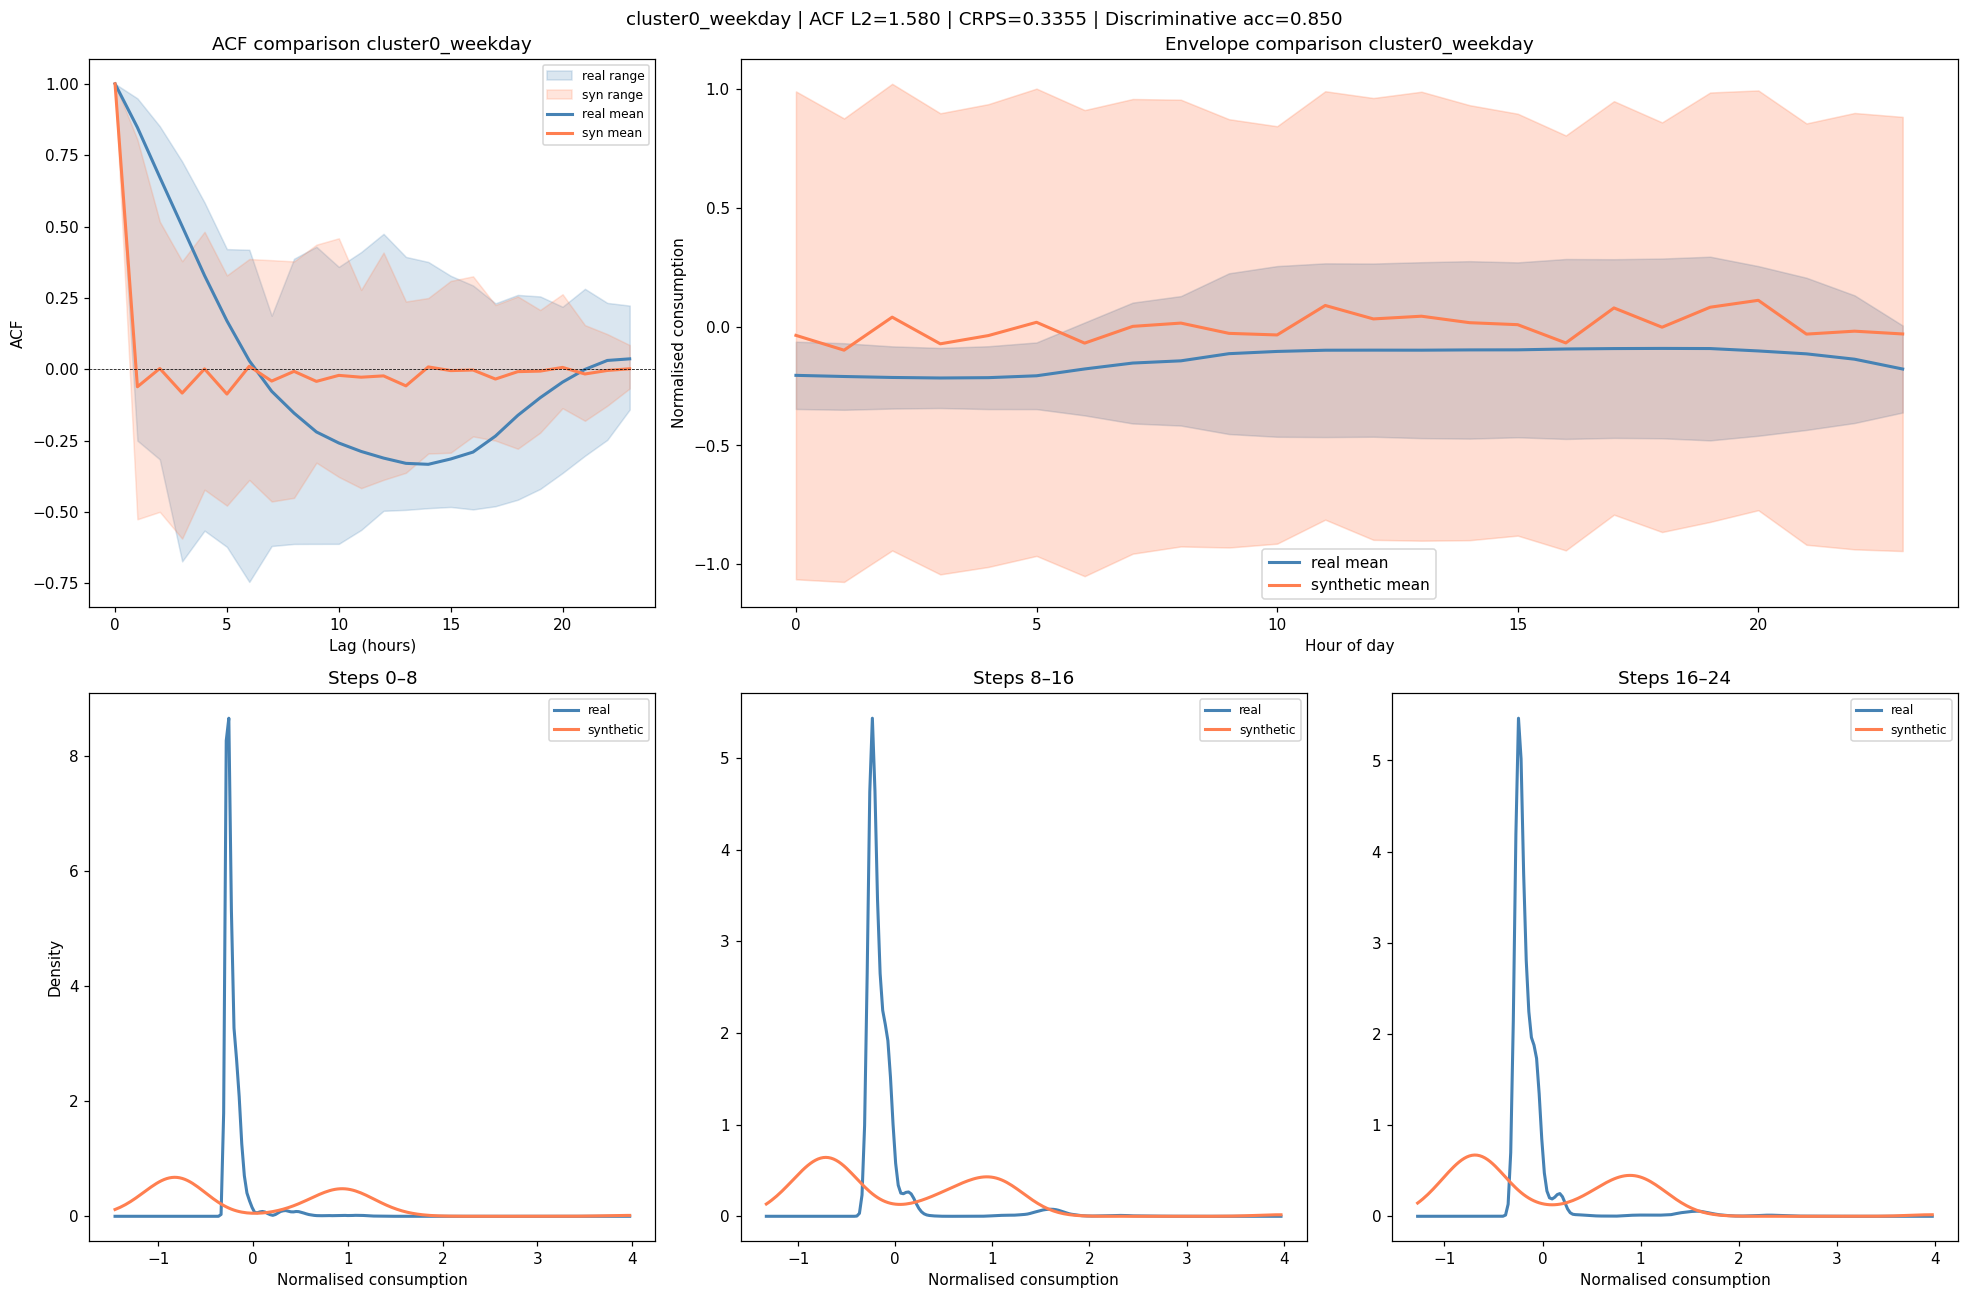

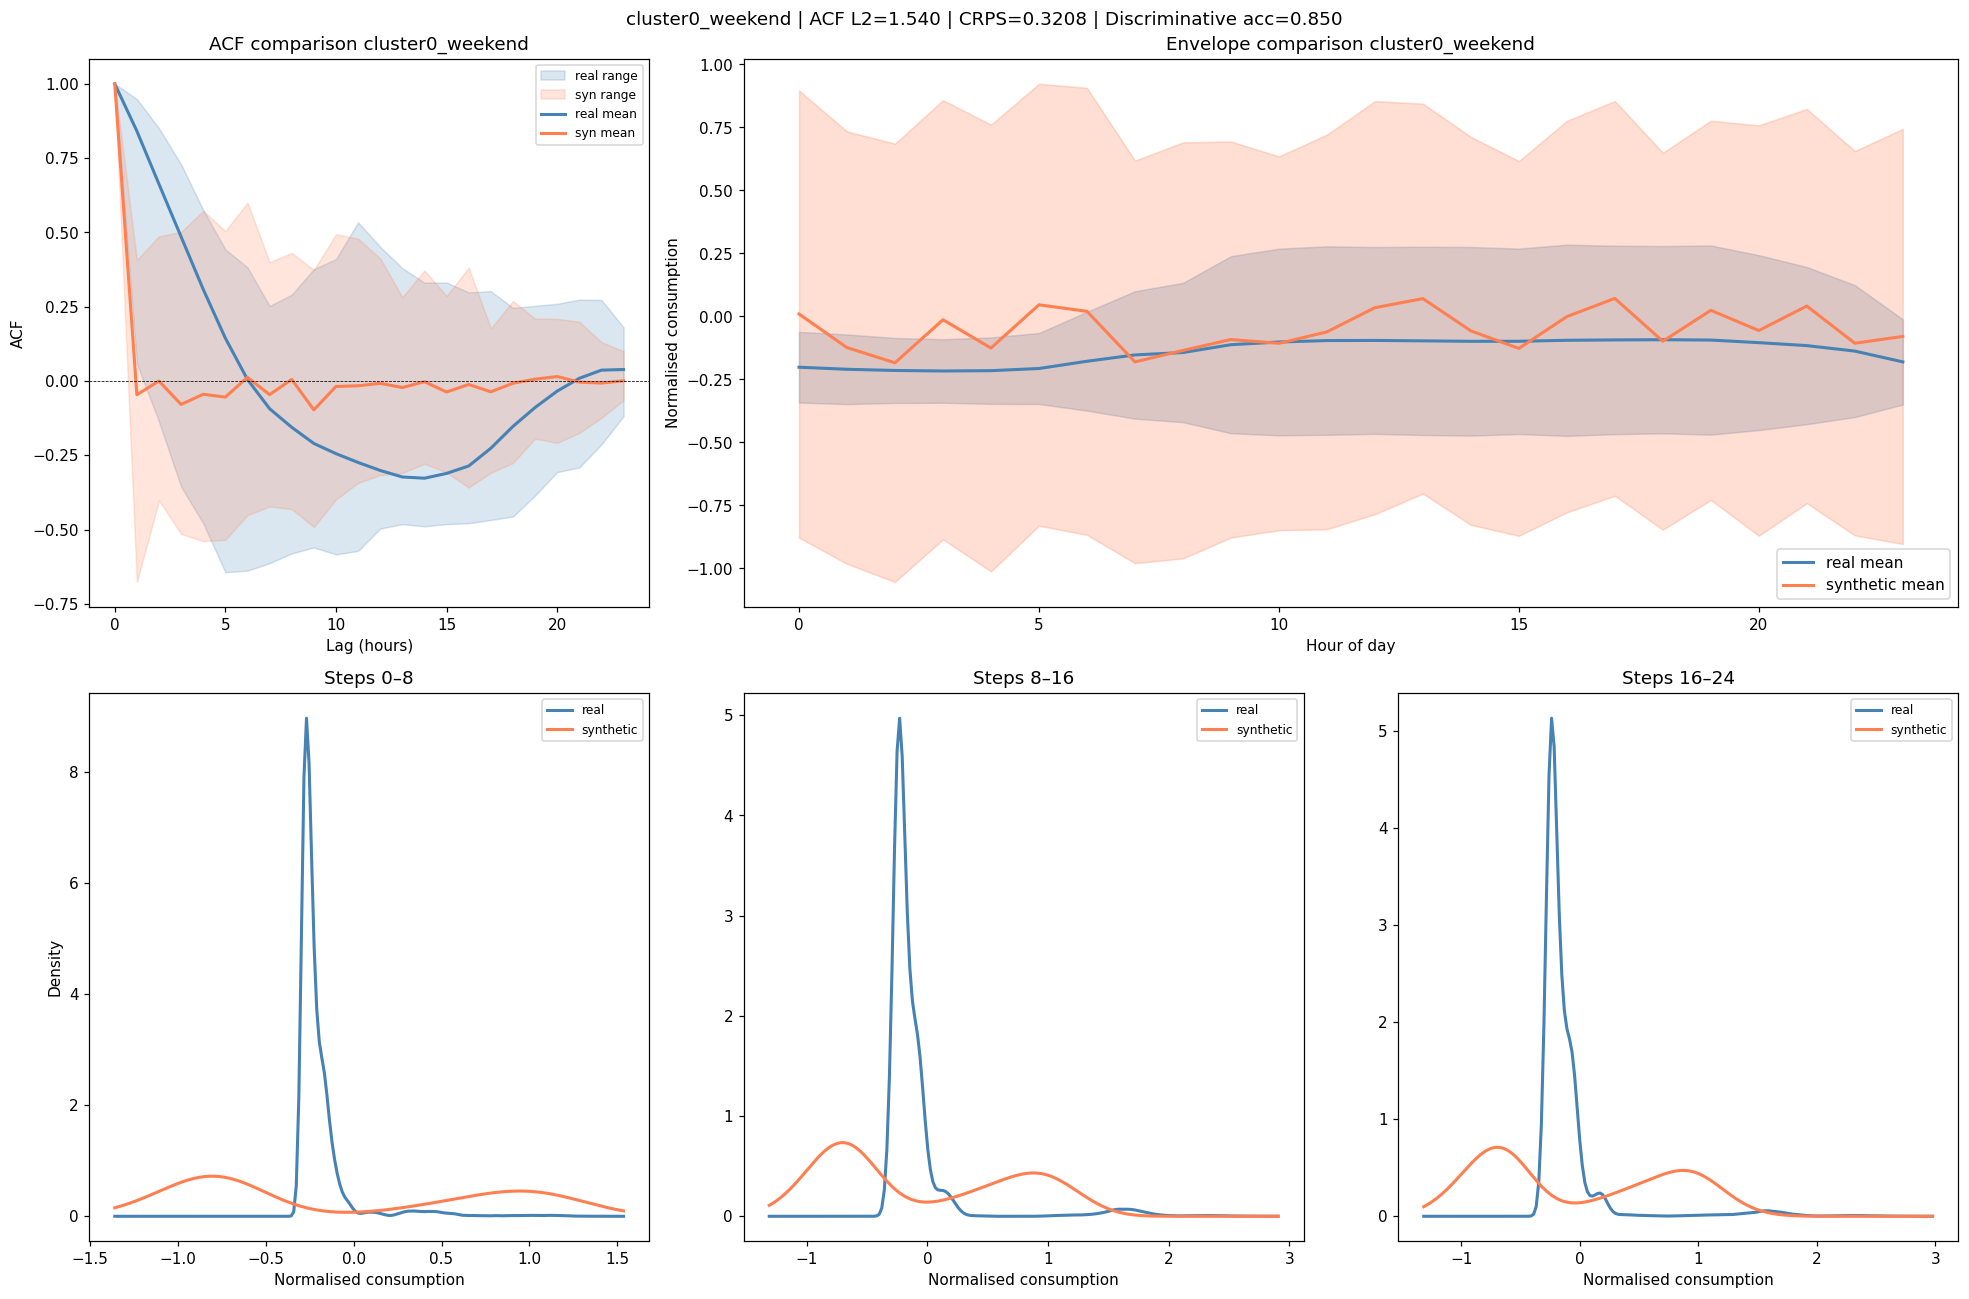

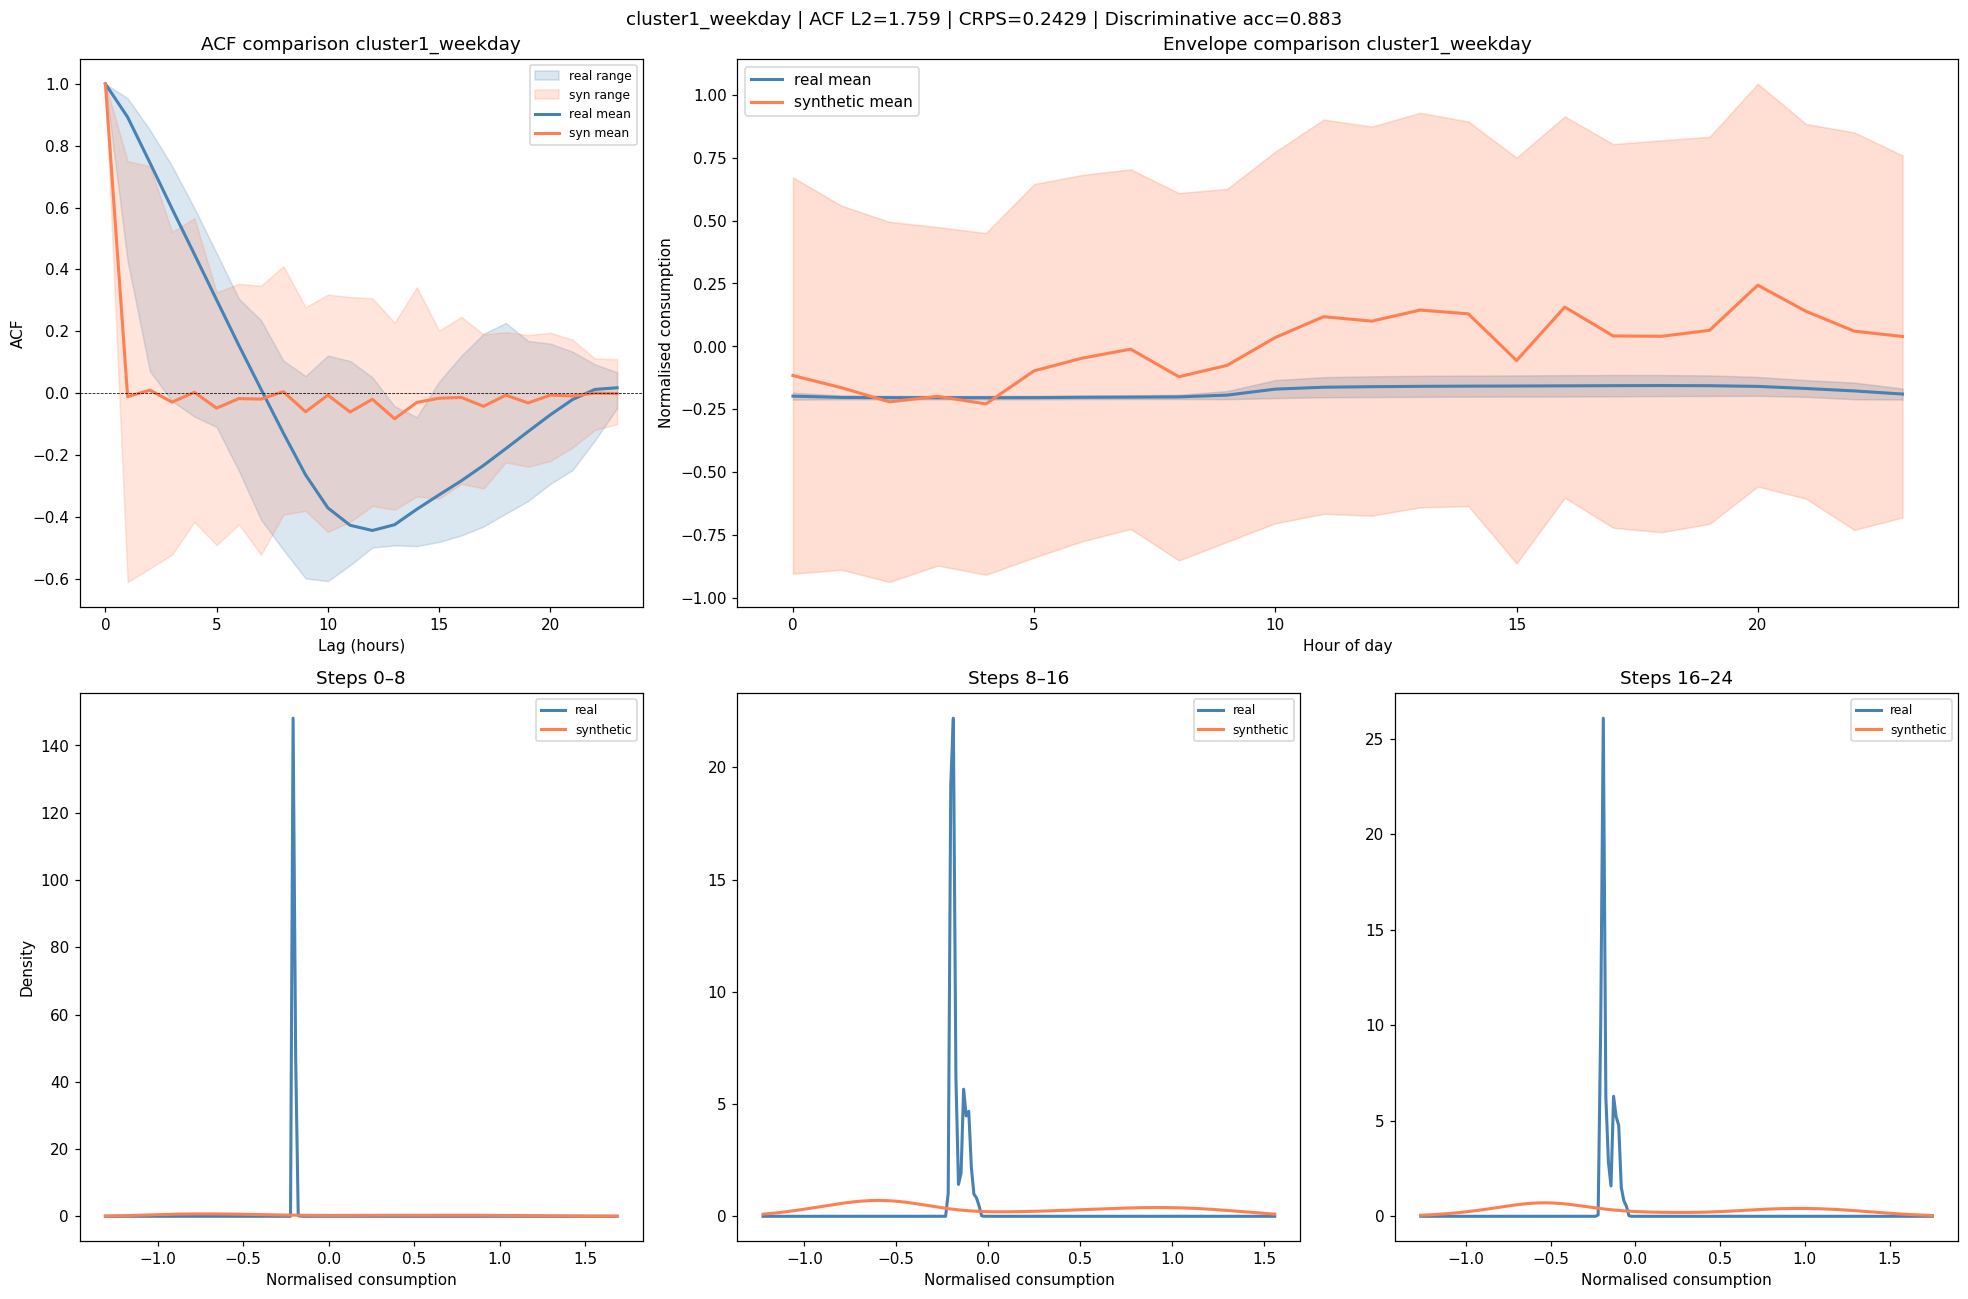

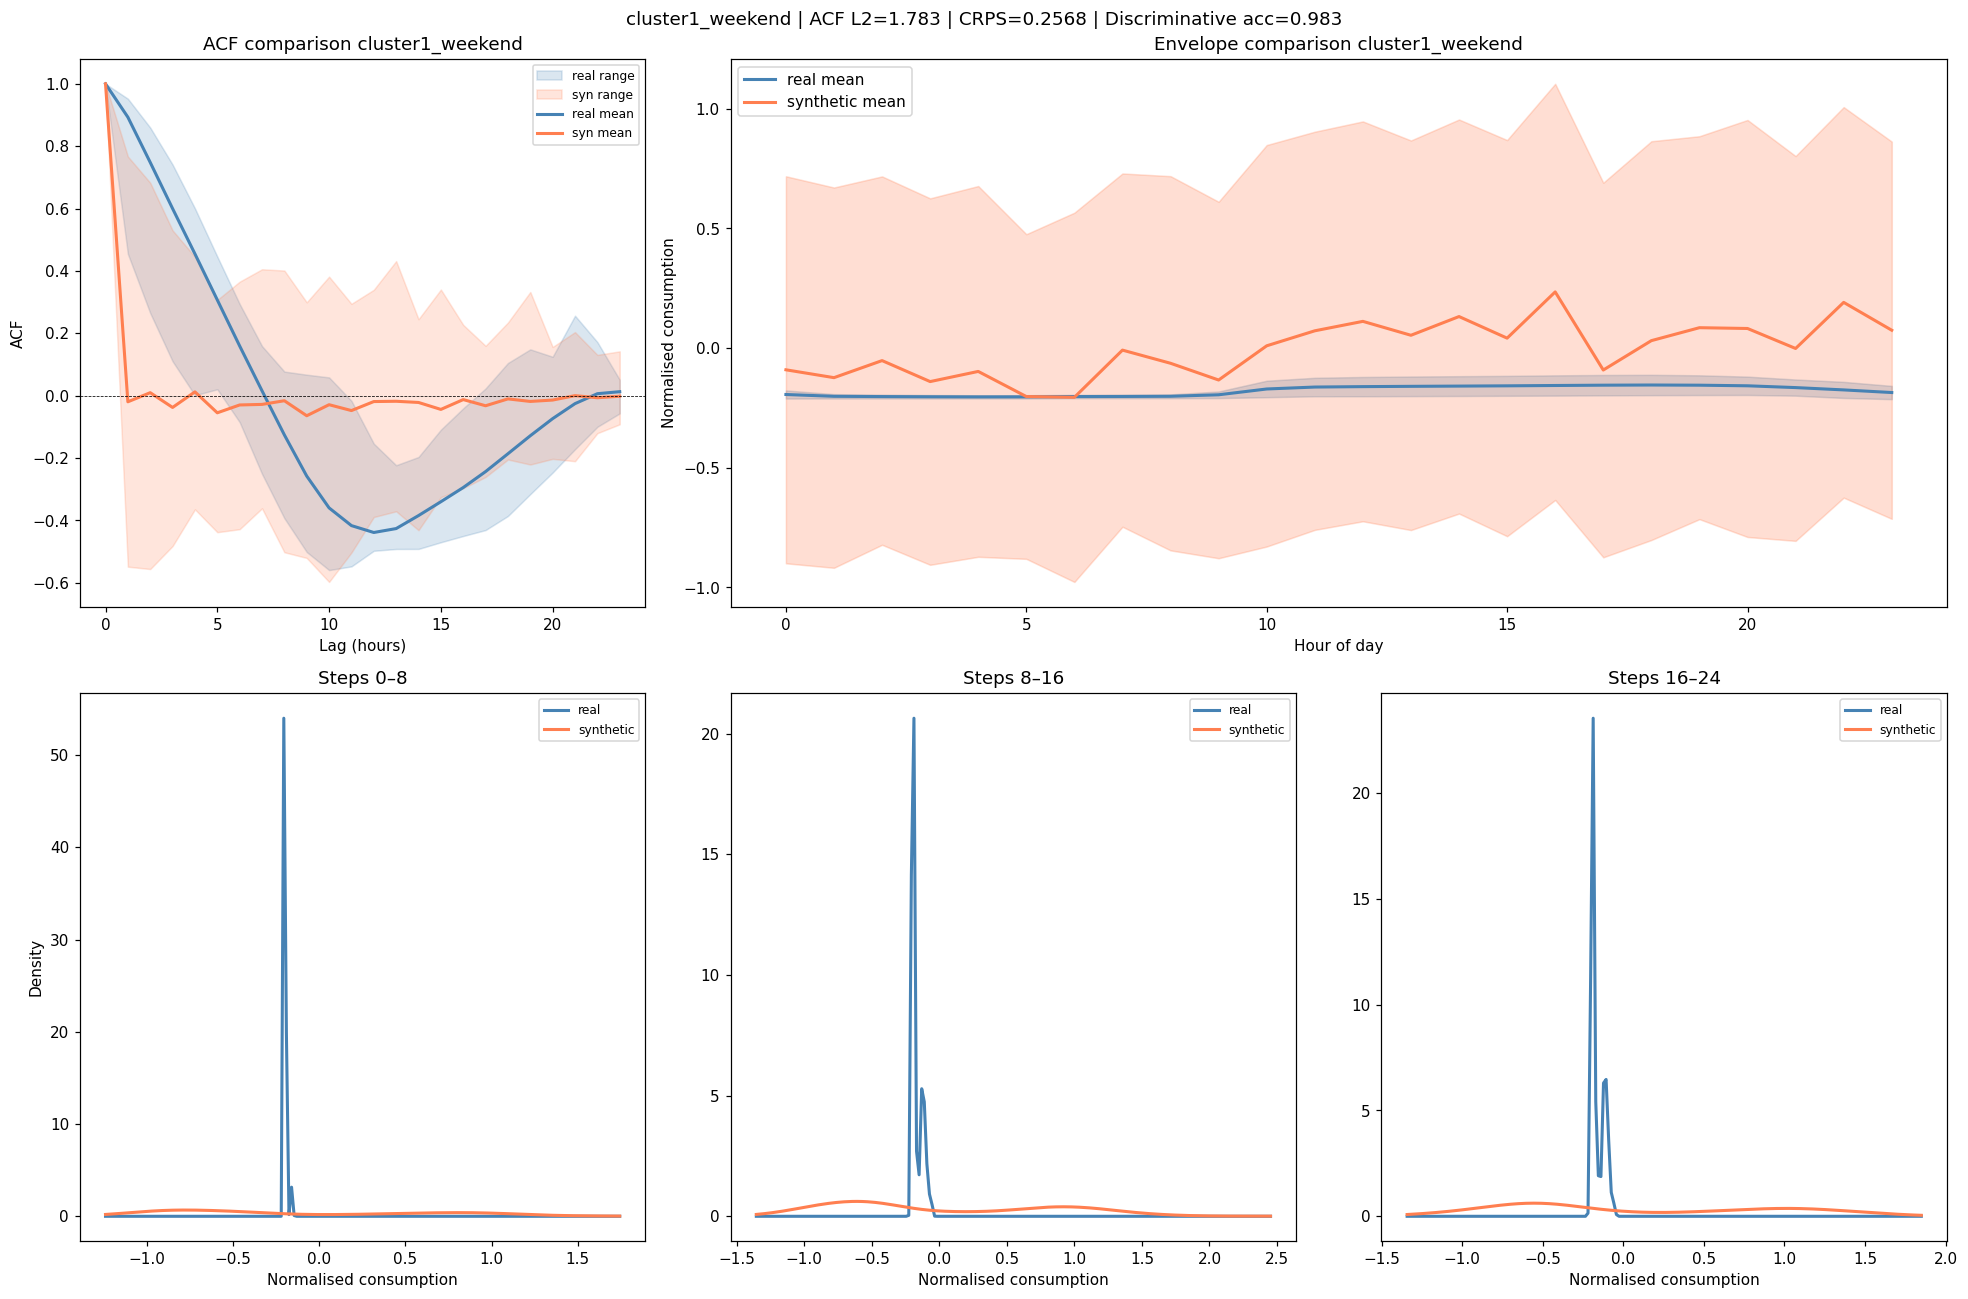

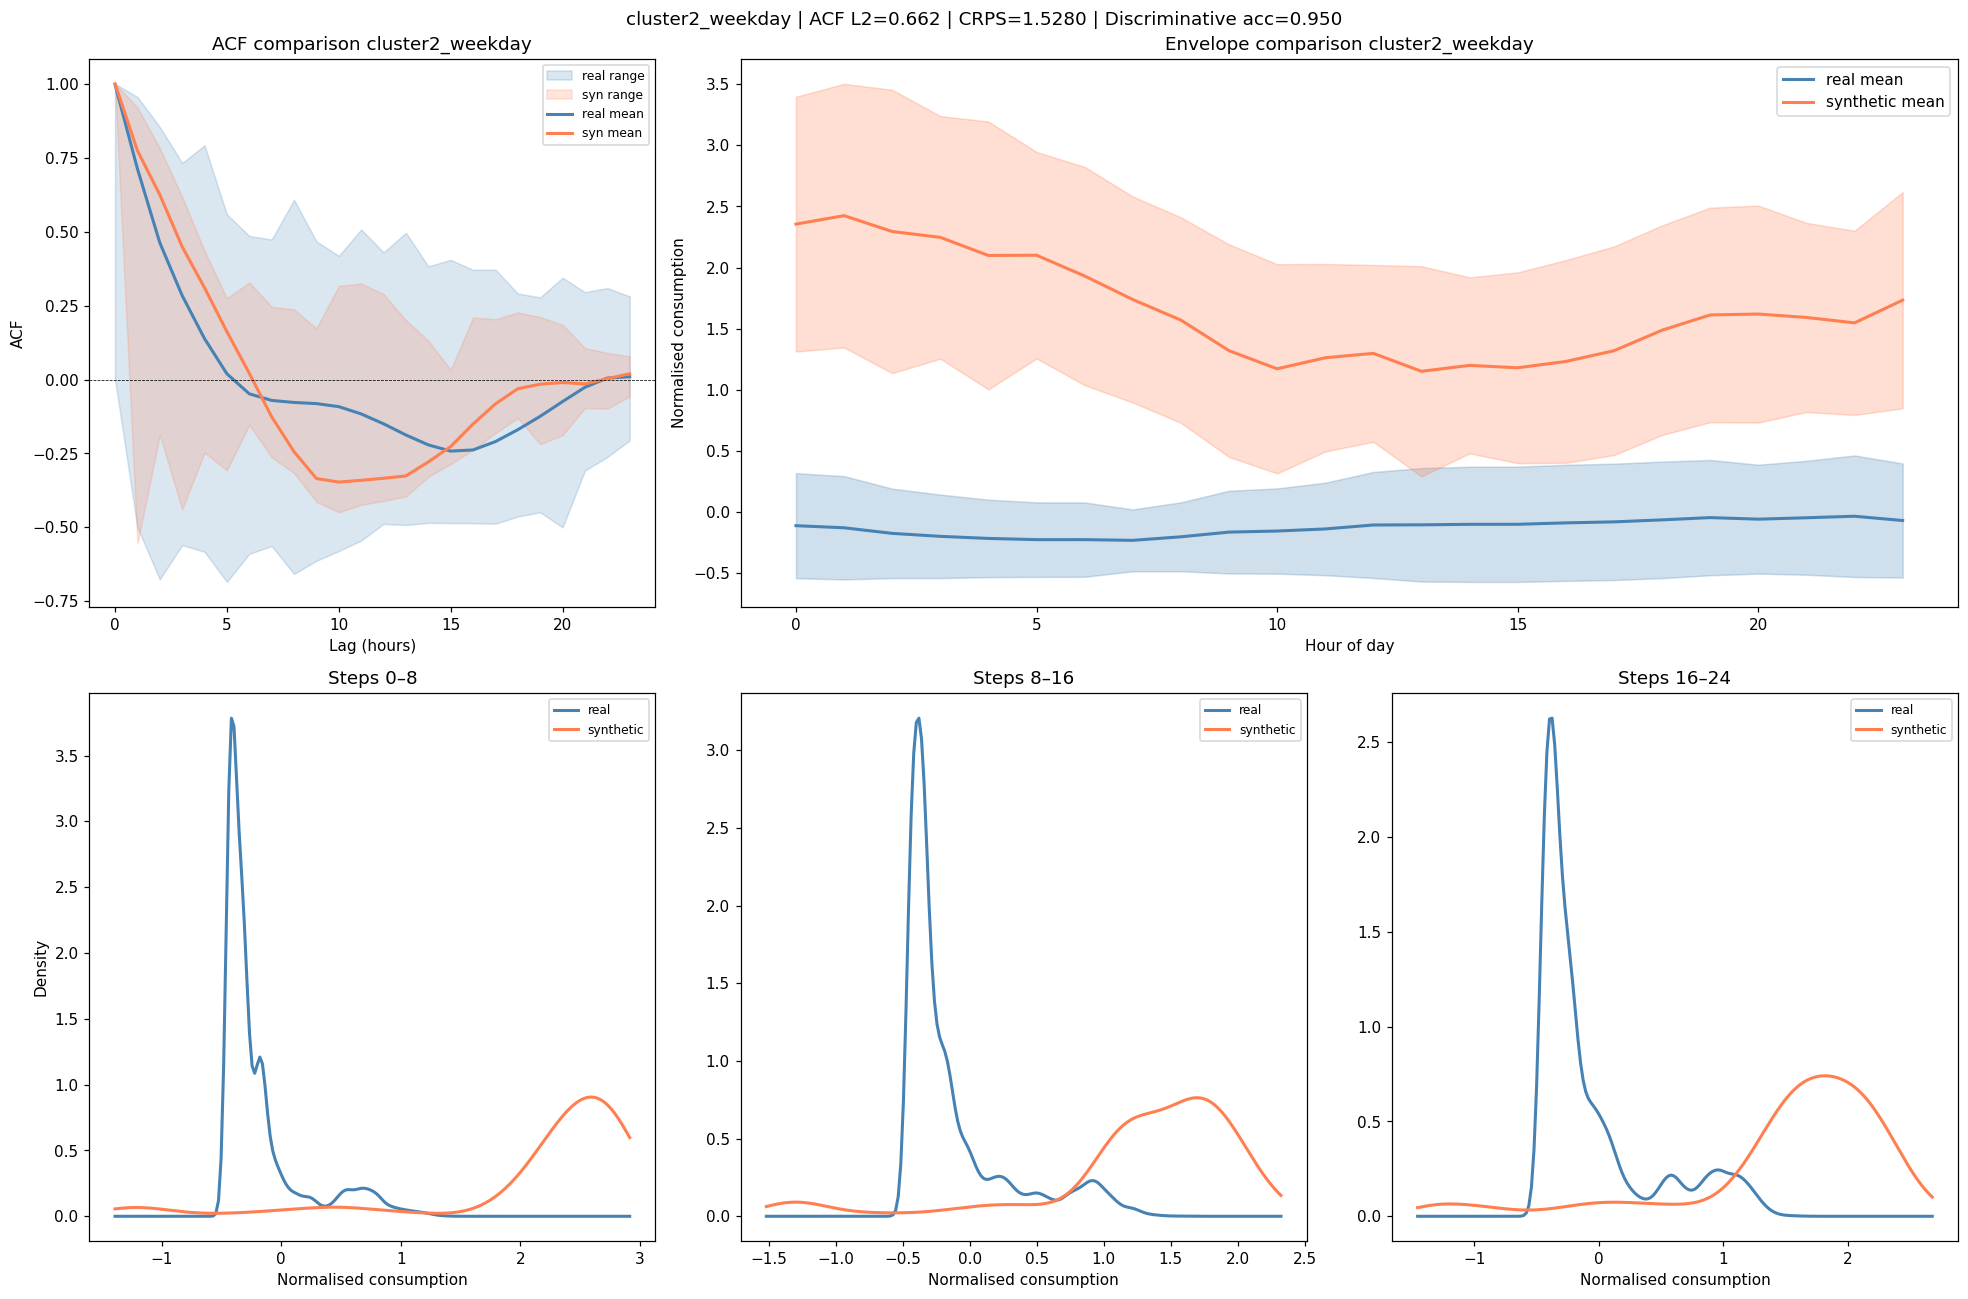

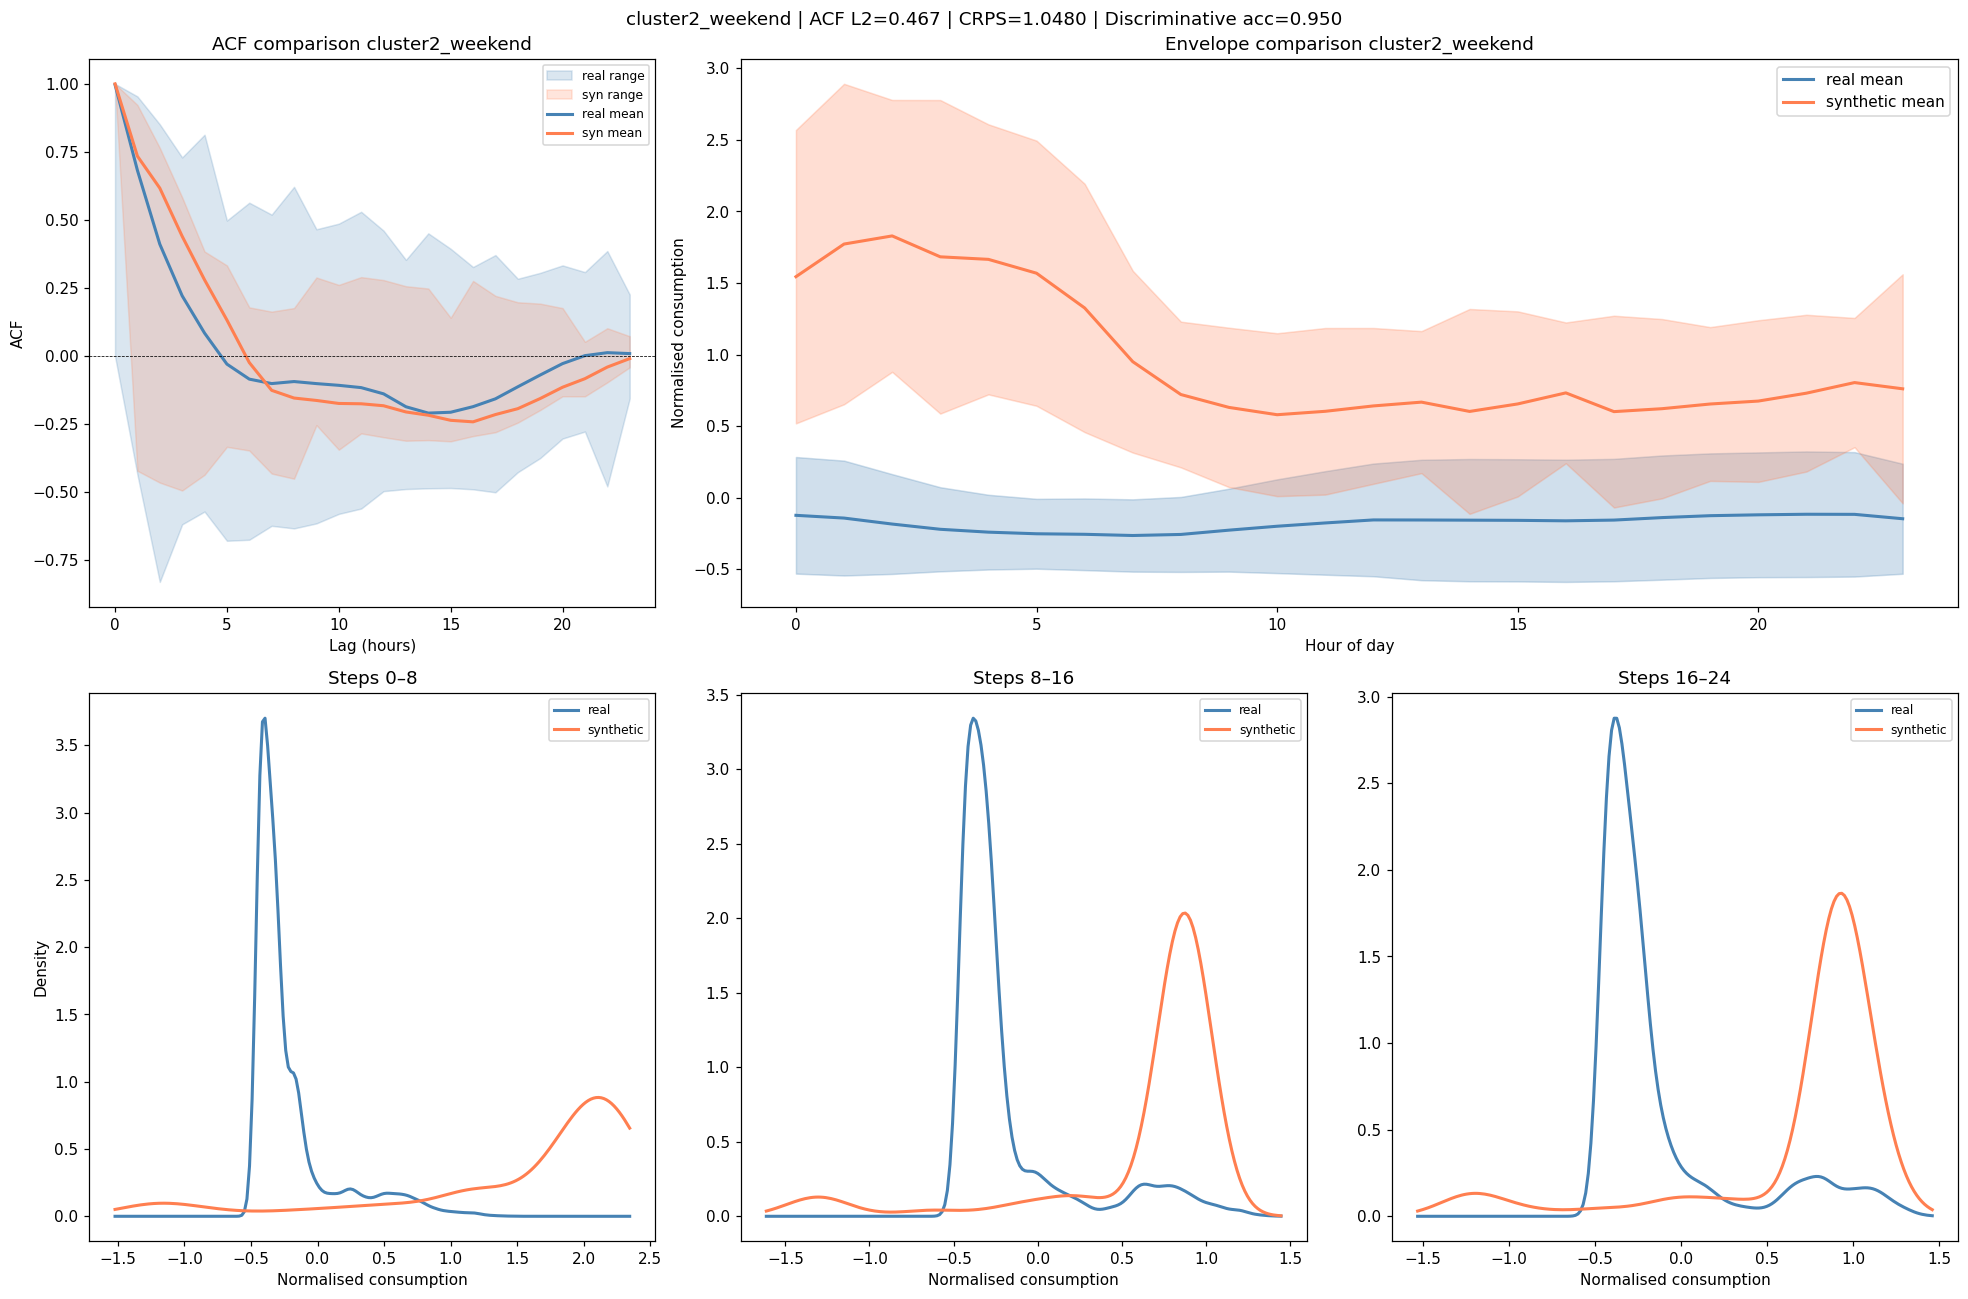

In [5]:
all_metric_rows = []

for label, data in results.items():
    print(f'\n=== {label} ===')
    m = run_all_metrics(data['real'], data['synthetic'], label=label)
    m['condition'] = label
    all_metric_rows.append(m)

metrics_df = pd.DataFrame(all_metric_rows).set_index('condition')
print('\n--- Summary ---')
print(metrics_df.to_string())

## 5. Summary table


Key metrics:
                  acf_l2    crps  discriminative_acc
condition                                           
cluster0_weekday  1.5800  0.3355              0.8500
cluster0_weekend  1.5402  0.3208              0.8500
cluster1_weekday  1.7589  0.2429              0.8833
cluster1_weekend  1.7825  0.2568              0.9833
cluster2_weekday  0.6623  1.5280              0.9500
cluster2_weekend  0.4674  1.0480              0.9500


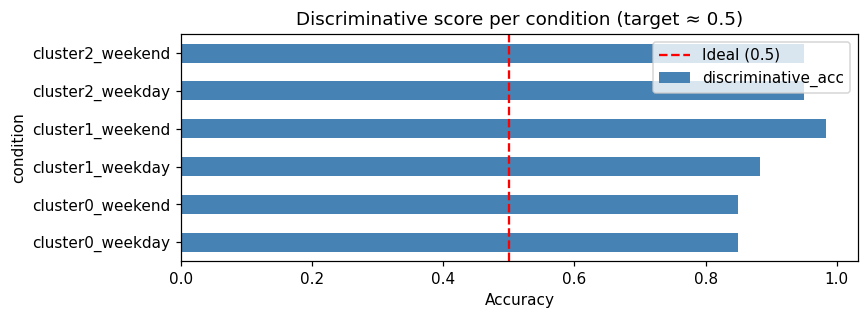

In [6]:
# Highlight key columns
key_cols = [c for c in ['acf_l2', 'crps', 'discriminative_acc'] if c in metrics_df.columns]
print('\nKey metrics:')
print(metrics_df[key_cols].round(4).to_string())

# Discriminative score bar chart with quality bands
if 'discriminative_acc' in metrics_df.columns:
    fig, ax = plt.subplots(figsize=(9, 3.5))
    metrics_df['discriminative_acc'].plot(kind='barh', ax=ax, color='steelblue', zorder=3)

    # Colour-coded quality bands
    ax.axvspan(0.48, 0.52, color='green',  alpha=0.15, label='Excellent (<0.52)')
    ax.axvspan(0.52, 0.60, color='yellow', alpha=0.20, label='Acceptable (<0.60)')
    ax.axvspan(0.60, 1.00, color='red',    alpha=0.08, label='Poor (>0.60)')
    ax.axvline(0.5, linestyle='--', color='black', linewidth=1.2, label='Ideal (0.5)')

    ax.set_xlim(0.4, 1.0)
    ax.set_xlabel('Accuracy')
    ax.set_title('Discriminative score per condition (target ≈ 0.5)')
    ax.legend(fontsize=8, loc='lower right')
    plt.tight_layout(); plt.show()


## 6. Denormalised visual comparison

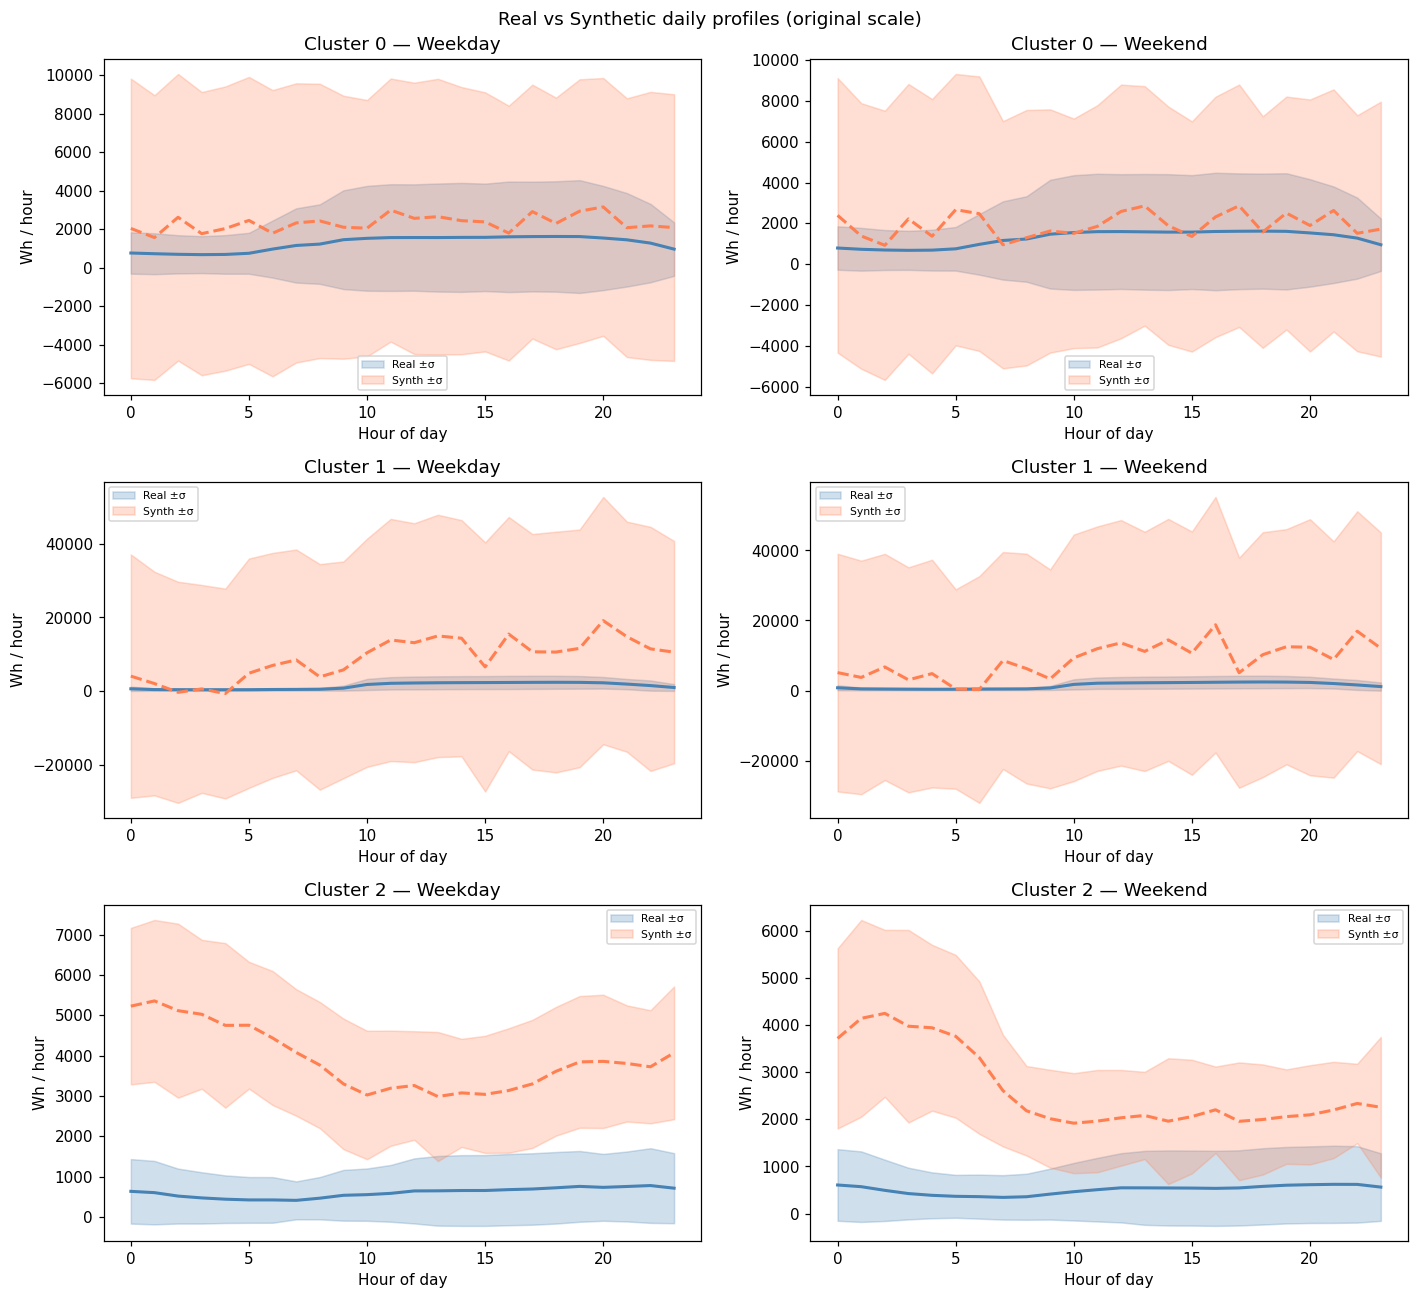

In [7]:

import importlib
import src.evaluation.metrics as _m
importlib.reload(_m)
from src.evaluation.metrics import per_timestep_stddev_plot

# Per-hour standard deviation comparison (normalised scale)
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(5 * N_CLUSTERS, 3.5), sharey=True)
if N_CLUSTERS == 1: axes = [axes]
for cid_val in range(N_CLUSTERS):
    ax = axes[cid_val]
    for dt, day_name in [(0, 'weekday'), (1, 'weekend')]:
        lbl = f'cluster{cid_val}_{day_name}'
        if lbl not in results: continue
        per_timestep_stddev_plot(
            results[lbl]['real'], results[lbl]['synthetic'],
            ax=ax, label=f'C{cid_val} {day_name}'
        )
    axes[cid_val].set_title(f'Cluster {cid_val}')
plt.suptitle('Per-hour σ: real vs synthetic (normalised scale)', fontsize=11)
plt.tight_layout(); plt.show()

# Denormalised mean profile comparison (original Wh scale)
hours = np.arange(24)
fig2, axes2 = plt.subplots(N_CLUSTERS, 2, figsize=(13, 4 * N_CLUSTERS))
if N_CLUSTERS == 1: axes2 = axes2[None, :]
for cid_val in range(N_CLUSTERS):
    for dt, day_name in enumerate(['Weekday', 'Weekend']):
        label = f'cluster{cid_val}_{day_name.lower()}'
        if label not in results: continue
        data = results[label]
        real_dn  = denormalize(data['real'],      cid_val, stats)
        synth_dn = denormalize(data['synthetic'], cid_val, stats)
        ax = axes2[cid_val, dt]
        mu_r, s_r = real_dn.mean(0),  real_dn.std(0)
        mu_s, s_s = synth_dn.mean(0), synth_dn.std(0)
        ax.fill_between(hours, mu_r - s_r, mu_r + s_r, alpha=0.25, color='steelblue', label='Real ±σ')
        ax.fill_between(hours, mu_s - s_s, mu_s + s_s, alpha=0.25, color='coral',     label='Synth ±σ')
        ax.plot(hours, mu_r, color='steelblue', linewidth=2)
        ax.plot(hours, mu_s, color='coral',     linewidth=2, linestyle='--')
        ax.set_title(f'Cluster {cid_val} — {day_name}')
        ax.set_xlabel('Hour'); ax.set_ylabel('Wh / hour')
        ax.legend(fontsize=7)
plt.suptitle('Real vs Synthetic daily profiles (original Wh scale)', fontsize=12)
plt.tight_layout(); plt.show()


## 7. Export metrics CSV

In [8]:
metrics_path = DATA_DIR / 'evaluation_metrics.csv'
metrics_df.to_csv(metrics_path)
print(f'Saved -> {metrics_path}')

Saved -> /tmp/vscode-colab/tesina/data/evaluation_metrics.csv


## 8. Observations & interpretation


In [9]:

# ── §8 Summary printout ──────────────────────────────────────────────────────

print("=" * 62)
print("EVALUATION SUMMARY")
print("=" * 62)

if 'discriminative_acc' in metrics_df.columns:
    print(f"\nDiscriminative accuracy  (ideal ≈ 0.50):")
    for cond, v in metrics_df['discriminative_acc'].items():
        offset  = abs(v - 0.5)
        quality = "good" if offset < 0.10 else ("fair" if offset < 0.20 else "poor")
        print(f"  {cond:<35s}  {v:.3f}  [{quality}]")

if 'crps' in metrics_df.columns:
    print(f"\nCRPS (lower = better predictive sharpness):")
    for cond, v in metrics_df['crps'].items():
        print(f"  {cond:<35s}  {v:.4f}")

if 'acf_l2' in metrics_df.columns:
    print(f"\nACF L2 distance  (lower = better temporal structure):")
    for cond, v in metrics_df['acf_l2'].items():
        print(f"  {cond:<35s}  {v:.4f}")

print()
print("Reference thresholds:")
print("  Discriminative acc: ≤0.60 acceptable | ≤0.55 good | ≤0.52 excellent")
print("  ACF L2: < 0.10 indicates good temporal correlation preservation")
print("  CRPS: compare relative improvement vs a naïve baseline (e.g., random real sample)")
print()
print("NOTE: results shown are from a short training run (QUICK_RUN).")
print("For thesis-quality evaluation, re-run after full GPU training (~200 epochs).")
print()
print("─" * 62)
print("WEEKDAY vs WEEKEND KDE OVERLAP — EXPECTED BEHAVIOUR")
print("─" * 62)
print(
    "  The raw data shows only ~1.4% mean difference between weekday\n"
    "  and weekend profiles (01_eda.ipynb §4b). Consequently, the\n"
    "  marginal KDE distributions of weekday vs weekend synthetic samples\n"
    "  will overlap almost completely. This is NOT a model failure — it\n"
    "  faithfully reflects the weak day_type signal in this dataset\n"
    "  (Portuguese smart meters, industrial/commercial mix).\n"
    "\n"
    "  The model learns cluster structure (C0 daytime bell, C1 midday\n"
    "  plateau, C2 evening peak) far more strongly than day_type.\n"
    "\n"
    "  Thesis Discussion framing:\n"
    "    • day_type conditioning is included for completeness and\n"
    "      future-proofing (residential-only datasets show stronger\n"
    "      weekday/weekend differences).\n"
    "    • The effect would become more pronounced with temperature\n"
    "      exogenous conditioning (planned future work).\n"
    "    • CFG guidance scale ablation (§9) probes whether higher s\n"
    "      sharpens the day_type separation — expected: minimal effect."
)


EVALUATION SUMMARY

Discriminative accuracy  (ideal ≈ 0.50):
  cluster0_weekday                     0.850  [poor]
  cluster0_weekend                     0.850  [poor]
  cluster1_weekday                     0.883  [poor]
  cluster1_weekend                     0.983  [poor]
  cluster2_weekday                     0.950  [poor]
  cluster2_weekend                     0.950  [poor]

CRPS (lower = better predictive sharpness):
  cluster0_weekday                     0.3355
  cluster0_weekend                     0.3208
  cluster1_weekday                     0.2429
  cluster1_weekend                     0.2568
  cluster2_weekday                     1.5280
  cluster2_weekend                     1.0480

ACF L2 distance  (lower = better temporal structure):
  cluster0_weekday                     1.5800
  cluster0_weekend                     1.5402
  cluster1_weekday                     1.7589
  cluster1_weekend                     1.7825
  cluster2_weekday                     0.6623
  cluster2_week

## 9. Guidance scale ablation


In [ ]:
# ── §9 Guidance scale sensitivity ─────────────────────────────────────────
# Generate samples for one representative condition at 4 guidance scales.
# Useful for choosing the best scale and as a thesis Discussion figure.

ABLATION_SCALES = [0.0, 1.0, 1.5, 2.5]
ABLATION_CID    = 0        # Cluster 0 (largest group)
ABLATION_DT     = 0        # Weekday
ABLATION_N      = 100      # samples per scale

scales_results = {}
mask_abl = (c_val[:, 0] == ABLATION_CID) & (c_val[:, 1] == ABLATION_DT)
real_abl = x_val[mask_abl]
print(f'Real windows for ablation: {real_abl.shape[0]}')

for scale in ABLATION_SCALES:
    rep_dow = 1   # Tuesday
    c_abl = jnp.array([[ABLATION_CID, ABLATION_DT, 5, rep_dow]] * ABLATION_N, dtype=jnp.int32)
    key_abl = jax.random.PRNGKey(int(scale * 10))
    synth_abl = diffusion.ddim_sample(
        trainer.model, c_abl,
        seq_len=24, batch_size=ABLATION_N,
        key=key_abl, n_steps=50, guidance_scale=scale,
    )
    scales_results[scale] = np.array(synth_abl)
    print(f'  scale={scale:.1f}: generated {ABLATION_N} samples')

# ── Plot: mean ±σ per guidance scale ──────────────────────────────────────
hours = np.arange(24)
fig, ax = plt.subplots(figsize=(10, 4))

mu_r = real_abl.mean(0)
s_r  = real_abl.std(0)
ax.fill_between(hours, mu_r - s_r, mu_r + s_r, alpha=0.2, color='steelblue')
ax.plot(hours, mu_r, color='steelblue', linewidth=2.5, label='Real')

colors = ['#e41a1c', '#ff7f00', '#4daf4a', '#984ea3']
for (scale, synth_s), col in zip(scales_results.items(), colors):
    mu_s = synth_s.mean(0)
    s_s  = synth_s.std(0)
    ax.fill_between(hours, mu_s - s_s, mu_s + s_s, alpha=0.12, color=col)
    ax.plot(hours, mu_s, color=col, linewidth=1.8, linestyle='--', label=f's={scale:.1f}')

ax.set_xlabel('Hour of day'); ax.set_ylabel('Normalised consumption')
ax.set_title(f'Guidance scale ablation — Cluster {ABLATION_CID} Weekday')
ax.legend(ncol=5, fontsize=9); plt.tight_layout(); plt.show()

# ── Scalar metrics per scale ───────────────────────────────────────────────
from src.evaluation.metrics import discriminative_score, crps_score, acf_compare
print(f'\n{"Scale":>6}  {"Disc. acc":>10}  {"CRPS":>8}  {"ACF L2":>8}')
for scale, synth_s in scales_results.items():
    disc_s = discriminative_score(real_abl, synth_s)
    crps_s = crps_score(real_abl, synth_s)
    acf_s  = acf_compare(real_abl, synth_s)
    print(f'{scale:>6.1f}  {disc_s:>10.3f}  {crps_s:>8.4f}  {acf_s:>8.4f}')
